# Krishna Menon
## B.Tech AI I045

# Experiment 5: Wasserstein GAN (WGAN) on Fashion-MNIST

This notebook implements a **WGAN** version of your GAN pipeline from EXP4.

## What is changed vs EXP4
- Discriminator is replaced by a **Critic** (no sigmoid output)
- Uses **Wasserstein loss** instead of BCE loss
- Trains critic multiple times per generator step (`n_critic`)
- Uses **weight clipping** to enforce Lipschitz constraint

In [19]:
%pip uninstall -y torch torchvision torchaudio
%pip install torch torchvision torchaudio matplotlib --index-url https://download.pytorch.org/whl/cu130

Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://download.pytorch.org/whl/cu130
  Using cached https://download-r2.pytorch.org/whl/cu130/torch-2.11.0%2Bcu130-cp312-cp312-win_amd64.whl.metadata (29 kB)
  Using cached https://download-r2.pytorch.org/whl/cu130/torchvision-0.26.0%2Bcu130-cp312-cp312-win_amd64.whl.metadata (5.6 kB)
  Using cached https://download-r2.pytorch.org/whl/cu130/torchaudio-2.11.0%2Bcu130-cp312-cp312-win_amd64.whl.metadata (7.0 kB)
   ---------------------------------------- 0.0/1.9 GB ? eta -:--:--
   ---------------------------------------- 0.0/1.9 GB 21.0 MB/s eta 0:01:31
   ---------------------------------------- 0.0/1.9 GB 22.2 MB/s eta 0:01:26
   ---------------------------------------- 0.0/1.9 GB 22.8 MB/s eta 0:01:24
   ---------------------------------------- 0.0/1.9 GB 22.0 MB/s eta 0:01:27
   ---------------------------------------- 0.0/1.9 GB 22.7 MB/s eta 0:01:24
    --------------------------------------- 0.0/1.9 GB 22.2 MB/s eta 0:01:25
    ------------------------------

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy

# Reproducibility
torch.manual_seed(111)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Using device:", device)

Torch: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))          

CUDA available: True
GPU: Tesla T4


In [4]:
# Data pipeline (same dataset choice as EXP4)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Scale images to [-1, 1]
])

train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)

batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=True)

print("Train samples:", len(train_data))
print("Classes:", train_data.classes)

100%|██████████| 26.4M/26.4M [00:00<00:00, 114MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.54MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 60.1MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.3MB/s]


Train samples: 60000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [5]:
# WGAN models
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.model(x)


class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.model(z)


def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)


latent_dim = 100
critic = Critic().to(device)
generator = Generator(latent_dim=latent_dim).to(device)
critic.apply(init_weights)
generator.apply(init_weights)

print("WGAN models initialized")

WGAN models initialized


In [6]:
# WGAN training setup
lr = 5e-5
num_epochs = 50
n_critic = 5          # Critic updates per generator update
clip_value = 0.01     # Weight clipping range for critic

optimizer_critic = torch.optim.RMSprop(critic.parameters(), lr=lr)
optimizer_generator = torch.optim.RMSprop(generator.parameters(), lr=lr)

critic_losses = []
generator_losses = []

print("Starting WGAN training...")

Starting WGAN training...


In [7]:
for epoch in range(num_epochs):
    epoch_c_loss = 0.0
    epoch_g_loss = 0.0

    for batch_idx, (real_images, _) in enumerate(train_loader):
        real_images = real_images.view(real_images.size(0), -1).to(device)
        current_batch_size = real_images.size(0)

        # -------------------------
        # Train Critic (maximize E[C(real)] - E[C(fake)])
        # -------------------------
        for _ in range(n_critic):
            z = torch.randn(current_batch_size, latent_dim, device=device)
            fake_images = generator(z).detach()

            critic_real = critic(real_images)
            critic_fake = critic(fake_images)

            loss_critic = -(torch.mean(critic_real) - torch.mean(critic_fake))

            optimizer_critic.zero_grad()
            loss_critic.backward()
            optimizer_critic.step()

            # Weight clipping enforces 1-Lipschitz condition in original WGAN
            for p in critic.parameters():
                p.data.clamp_(-clip_value, clip_value)

        # -------------------------
        # Train Generator (minimize -E[C(fake)])
        # -------------------------
        z = torch.randn(current_batch_size, latent_dim, device=device)
        fake_images = generator(z)
        loss_generator = -torch.mean(critic(fake_images))

        optimizer_generator.zero_grad()
        loss_generator.backward()
        optimizer_generator.step()

        epoch_c_loss += loss_critic.item()
        epoch_g_loss += loss_generator.item()

    avg_c_loss = epoch_c_loss / len(train_loader)
    avg_g_loss = epoch_g_loss / len(train_loader)
    critic_losses.append(avg_c_loss)
    generator_losses.append(avg_g_loss)

    if epoch % 5 == 0:
        print(f"Epoch [{epoch}/{num_epochs}] | Critic Loss: {avg_c_loss:.4f} | Generator Loss: {avg_g_loss:.4f}")

print("WGAN training complete")

Epoch [0/50] | Critic Loss: -2.5960 | Generator Loss: -1.3843
Epoch [5/50] | Critic Loss: -1.5795 | Generator Loss: -2.2791
Epoch [10/50] | Critic Loss: -1.2735 | Generator Loss: 1.2037
Epoch [15/50] | Critic Loss: -0.9106 | Generator Loss: -0.2516
Epoch [20/50] | Critic Loss: -0.6035 | Generator Loss: -0.1273
Epoch [25/50] | Critic Loss: -0.5186 | Generator Loss: -0.2884
Epoch [30/50] | Critic Loss: -0.4627 | Generator Loss: -0.3429
Epoch [35/50] | Critic Loss: -0.4121 | Generator Loss: -0.4904
Epoch [40/50] | Critic Loss: -0.3721 | Generator Loss: -0.3819
Epoch [45/50] | Critic Loss: -0.3500 | Generator Loss: -0.3413
WGAN training complete


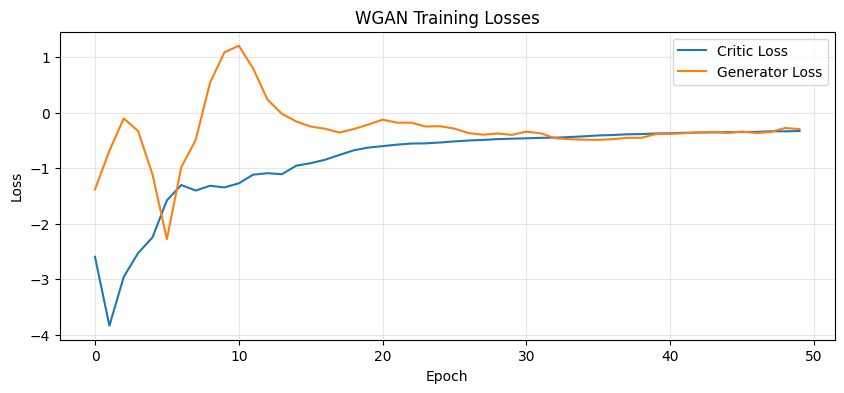

In [8]:
# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(critic_losses, label="Critic Loss")
plt.plot(generator_losses, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("WGAN Training Losses")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

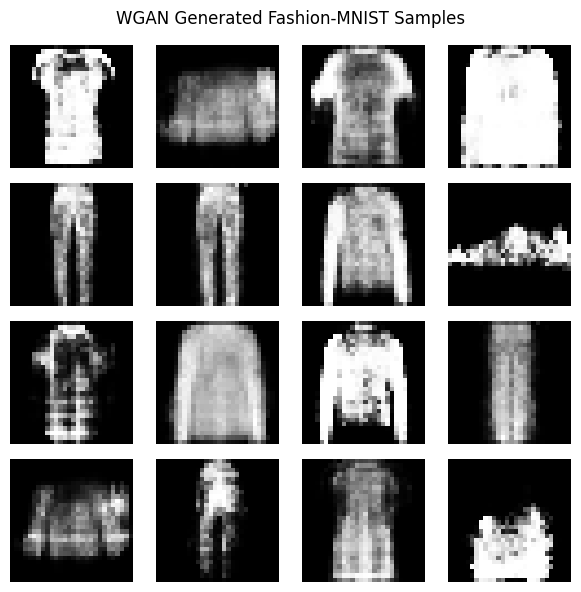

In [9]:
# Generate and visualize samples
num_samples = 16
generator.eval()
with torch.no_grad():
    z = torch.randn(num_samples, latent_dim, device=device)
    fake_images = generator(z).view(num_samples, 1, 28, 28)

# Unnormalize from [-1, 1] to [0, 1]
fake_images = (fake_images * 0.5 + 0.5).clamp(0, 1).cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(fake_images[i].squeeze(), cmap="gray")
    ax.axis("off")

plt.suptitle("WGAN Generated Fashion-MNIST Samples", fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# Save WGAN checkpoint
save_path = "fashion_mnist_wgan_checkpoint.pth"

torch.save(
    {
        "epoch": num_epochs,
        "generator_state_dict": generator.state_dict(),
        "critic_state_dict": critic.state_dict(),
        "optimizer_generator_state_dict": optimizer_generator.state_dict(),
        "optimizer_critic_state_dict": optimizer_critic.state_dict(),
        "latent_dim": latent_dim,
        "lr": lr,
        "n_critic": n_critic,
        "clip_value": clip_value,
    },
    save_path,
)

print(f"WGAN checkpoint saved to: {save_path}")

WGAN checkpoint saved to: fashion_mnist_wgan_checkpoint.pth


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import os
import shutil
from google.colab import drive
drive_save_dir = '/content/drive/MyDrive/ATML/EXP5_WGAN'
os.makedirs(drive_save_dir, exist_ok=True)
# 3. Copy the local checkpoint to Drive
local_ckpt = 'fashion_mnist_wgan_checkpoint.pth'
drive_ckpt = os.path.join(drive_save_dir, local_ckpt)
shutil.copy2(local_ckpt, drive_ckpt)
# 4. Confirm
size_mb = os.path.getsize(drive_ckpt) / (1024 ** 2)
print(f'Checkpoint saved to Drive: {drive_ckpt}')
print(f'File size: {size_mb:.2f} MB')

Checkpoint saved to Drive: /content/drive/MyDrive/ATML/EXP5_WGAN/fashion_mnist_wgan_checkpoint.pth
File size: 8.51 MB


## Gradio Frontend Launch

In [22]:
# ── Gradio Frontend for WGAN Image Generation ─────────────────────────────
import gradio as gr
import torch
import numpy as np
from PIL import Image

# ---- Re-use the already-loaded generator (from training cells above) ----
# If running this cell standalone, load from checkpoint:
# checkpoint = torch.load('fashion_mnist_wgan_checkpoint.pth', map_location=device)
# generator.load_state_dict(checkpoint['generator_state_dict'])

generator.eval()

FASHION_MNIST_LABELS = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def generate_images(num_images: int, seed: int):
    torch.manual_seed(int(seed))
    z = torch.randn(int(num_images), latent_dim, device=device)
    with torch.no_grad():
        fake = generator(z).view(int(num_images), 1, 28, 28)
    fake = (fake * 0.5 + 0.5).clamp(0, 1).cpu().numpy()  # [N, 1, 28, 28]

    # Build a grid image
    cols = min(int(num_images), 8)
    rows = (int(num_images) + cols - 1) // cols
    grid = np.ones((rows * 28 + (rows - 1) * 2,
                    cols * 28 + (cols - 1) * 2), dtype=np.float32)
    for idx in range(int(num_images)):
        r, c = divmod(idx, cols)
        y, x = r * 30, c * 30
        grid[y:y+28, x:x+28] = fake[idx, 0]

    img = Image.fromarray((grid * 255).astype(np.uint8))
    return img

with gr.Blocks(title="WGAN Fashion-MNIST Generator") as app:
    gr.Markdown("## 👗 WGAN Fashion-MNIST Image Generator")
    gr.Markdown("Generate synthetic Fashion-MNIST images using the trained WGAN.")
    with gr.Row():
        num_slider  = gr.Slider(1, 16, value=8, step=1,  label="Number of Images")
        seed_slider = gr.Slider(0, 9999, value=42, step=1, label="Random Seed")
    btn = gr.Button("Generate", variant="primary")
    out = gr.Image(label="Generated Images", type="pil")
    btn.click(fn=generate_images, inputs=[num_slider, seed_slider], outputs=out)

app.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0ce8e79d39858265b5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
%pip install gradio pillow

ERROR: Could not find a version that satisfies the requirement gradio_app (from versions: none)
ERROR: No matching distribution found for gradio_app
